In [8]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import matplotlib
import random
import json
import os

"""
This file creates the plots 3D (across iterations) plots under the PCA folder. Must input iteration .json file,
path, list of words that you are "comparing" (really just the analogy list), and how many components for PCA (3).

"""
# 3D PCA rendering

from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting

def pca_plot(data, fpath, comparing, n_components=2):
    points = []
    for word in comparing:
        points.extend([word, np.array(row)] for row in data[word])
    random.shuffle(points)

    labels = np.array([point[0] for point in points])
    lookup, clabels = np.unique(labels, return_inverse=True)
    vectors = np.array([point[1] for point in points])

    # Perform PCA
    pca = PCA(n_components=n_components)
    features_pca = pca.fit_transform(vectors)

    # Generate discrete color map
    base_cmap = matplotlib.colormaps.get_cmap('tab10')
    colors = base_cmap(np.linspace(0, 1, len(comparing)))
    cmap = ListedColormap(colors)

    # Create plot
    if n_components == 2:
        plt.figure(figsize=(5, 5))
        plt.scatter(features_pca[:, 0], features_pca[:, 1], c=clabels, cmap='tab10', s=5, marker='.')
        plt.xlabel('PC 1 (%.2f%%)' % (pca.explained_variance_ratio_[0]*100))
        plt.ylabel('PC 2 (%.2f%%)' % (pca.explained_variance_ratio_[1]*100))
        plt.title(fpath.split('/')[-1].split('.')[0])
    elif n_components == 3:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(features_pca[:, 0], features_pca[:, 1], features_pca[:, 2], c=clabels, cmap='tab10', s=5)
        ax.set_xlabel('PC 1 (%.2f%%)' % (pca.explained_variance_ratio_[0]*100))
        ax.set_ylabel('PC 2 (%.2f%%)' % (pca.explained_variance_ratio_[1]*100))
        ax.set_zlabel('PC 3 (%.2f%%)' % (pca.explained_variance_ratio_[2]*100))
        plt.title(fpath.split('/')[-1].split('.')[0])
    else:
        raise ValueError("n_components must be 2 or 3 for plotting.")

    # Add legend
    legend_patches = [mpatches.Patch(color=cmap(b)) for b in range(len(comparing))]
    plt.legend(legend_patches, lookup)

    # Save and show
    #outpath = fpath.replace('.png', f'{fpath}.png')
    plt.savefig(fpath, dpi=300)
    plt.show()


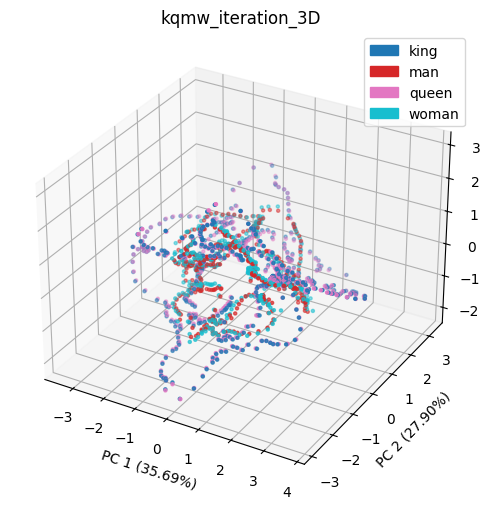

In [9]:
labelfile = 'data/kqmw_iteration.json'

#THIS WILL SHOW THE CHANGE OF THE VECTOR THROUGH EACH NEW SENTENCE CONSIDERED (NEIGHBORHOOD)
#with open('data/indiv_word_representations/generate_vector_from_iterative_vectors.json', 'r') as f:
#    vectors_from_iterative_vectors = json.load(f)


#THIS WILL SHOW THE CHANGE IN VECTORS THOUGHOUT ITERATIONS (1-400)
with open(labelfile, 'r') as f:
    iterations = json.load(f)

words = list(iterations.keys())
prefix = ''.join([w[0] for w in words])

 
# CAN SAMPLE EVERY 10th iteration, IF NEEDED REPLACE "iterations"
#sampled_10 = {word:[iterations[word][i] for i in range(0,len(iterations[word]),10)] for word in iterations}

pca_plot(iterations, f'pca/{prefix}_iteration_3D.png', words, 3)